## STEP 0. IMPORTING LIBRARIES


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb


## STEP 1. UNDERSTAND PROBLEMS AND DATA

In [2]:
df = pd.read_csv("credit_card.csv", sep = r'\s+')

### 1.1. Describe statistics of data

In [8]:
df.tail()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,...,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

####  Feature Description

| Feature | Description | Details / Values |
| :--- | :--- | :--- |
| **ID** | Client ID | ID of each client |
| **LIMIT_BAL** | Credit Limit | Amount of given credit in NT dollars (includes individual and family/supplementary credit) |
| **SEX** | Gender | 1 = Male, 2 = Female |
| **EDUCATION** | Education Level | 1 = Graduate school, 2 = University, 3 = High school, 4 = Others, 5 = Unknown, 6 = Unknown |
| **MARRIAGE** | Marital Status | 1 = Married, 2 = Single, 3 = Others |
| **AGE** | Age | Age in years |
| **PAY_0** | Repayment status in Sep, 2005 | -1 = Pay duly, 1 = Delay 1 month, 2 = Delay 2 months, ..., 8 = Delay 8 months, 9 = Delay 9+ months |
| **PAY_2** | Repayment status in Aug, 2005 | Scale same as PAY_0 |
| **PAY_3** | Repayment status in Jul, 2005 | Scale same as PAY_0 |
| **PAY_4** | Repayment status in Jun, 2005 | Scale same as PAY_0 |
| **PAY_5** | Repayment status in May, 2005 | Scale same as PAY_0 |
| **PAY_6** | Repayment status in Apr, 2005 | Scale same as PAY_0 |
| **BILL_AMT1 to BILL_AMT6** | Amount of bill statement | Bill statement amount (NT dollar) from Sep, 2005 (BILL_AMT1) to Apr, 2005 (BILL_AMT6) |
| **PAY_AMT1 to PAY_AMT6** | Amount of previous payment | Amount of previous payment (NT dollar) from Sep, 2005 (PAY_AMT1) to Apr, 2005 (PAY_AMT6) |
| **default.payment.next.month** | Default payment status | Target variable (1 = Yes, 0 = No) |

In [11]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### 1.2. Data cleaning

In [3]:
df = df.rename(columns = {
    'PAY_0':'PAY_1', 
    'default.payment.next.month':'Default'
})

In [4]:
df['EDUCATION'] = df['EDUCATION'].replace({0:4, 5:4, 6:4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0:3})

In [5]:
for i in range(1, 7):
    bill_col = f'BILL_AMT{i}'
    util_col = f'UTIL_RATIO_{i}'
    df[util_col] = np.maximum(df[bill_col], 0) / df['LIMIT_BAL']

# Tính trung bình tỷ lệ sử dụng hạn mức trong 6 tháng gần nhất
util_cols = [f'UTIL_RATIO_{i}' for i in range(1, 7)]
df['AVG_UTIL_RATIO'] = df[util_cols].mean(axis=1)

In [ ]:
for i in range(1, 6):
    pay_col = f'PAY_AMT{i}'
    prev_bill_col = f'BILL_AMT{i+1}'
    pay_ratio_col = f'PAY_RATIO_{i}'
    
    df[pay_ratio_col] = np.where(
        df[prev_bill_col] > 0,
        df[pay_col] / df[prev_bill_col],
        np.where(df[pay_col] > 0, 1.0, 0.0)
    )
    df[pay_ratio_col] = df[pay_ratio_col].clip(upper=1.0)

# Tính trung bình tỷ lệ trả nợ trong 5 chu kỳ
pay_ratio_cols = [f'PAY_RATIO_{i}' for i in range(1, 5)]
df['AVG_PAY_RATIO'] = df[pay_ratio_cols].mean(axis=1)

In [ ]:
pay_cols = [f'PAY_{i}' for i in range(1, 7)]
df['TOTAL_DELAY_MONTHS'] = df[pay_cols].apply(lambda row: sum([val for val in row if val > 0]), axis=1)

df['EVER_SERIOUS_DELAY'] = df[pay_cols].apply(lambda row: int(any(val >= 2 for val in row)), axis=1)

### 1.3. Data visualization

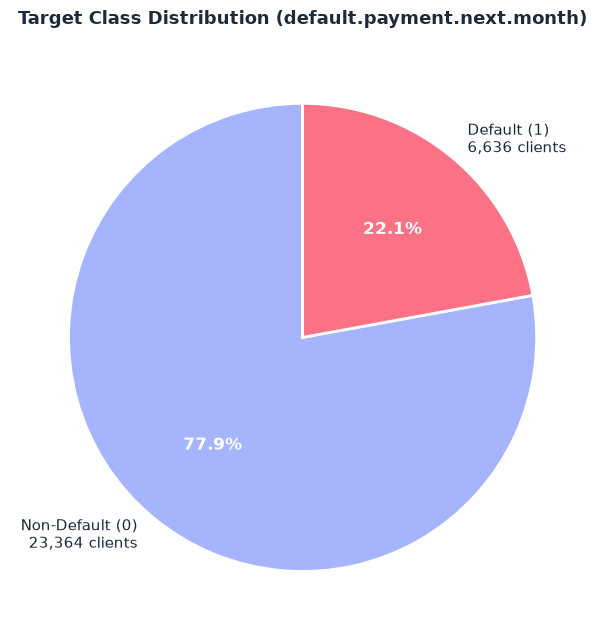

In [ ]:
target_col = 'Default'

counts = df[target_col].value_counts()
labels = [
    f'Non-Default (0)\n{counts[0]:,} clients',
    f'Default (1)\n{counts[1]:,} clients',
]
sizes = [counts[0], counts[1]]

colors = ['#A5B4FC', '#FB7185']

fig, ax = plt.subplots(figsize=(6.5, 6.5), dpi=100)

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=None, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.0},
    textprops={'fontsize': 10.5, 'color': '#1E293B'},
)

for autotext in autotexts:
  autotext.set_color('white')
  autotext.set_weight('bold')
  autotext.set_fontsize(12)

plt.title(
    'Target Class Distribution (default.payment.next.month)',
    fontsize=13,
    fontweight='bold',
    pad=15,
    color='#1E293B',
)

plt.tight_layout()
plt.show()

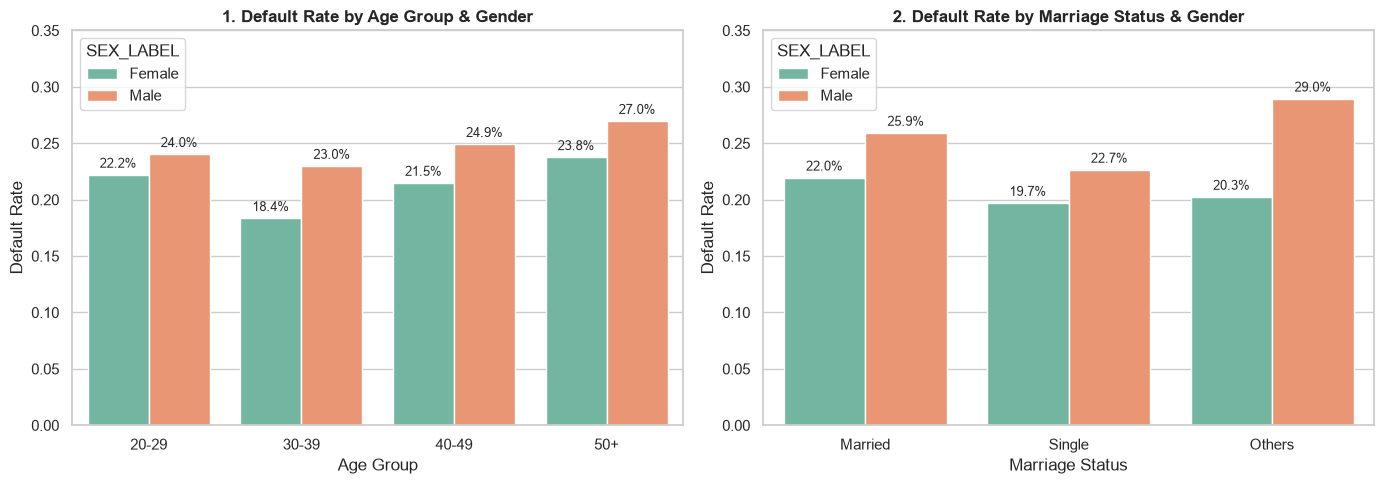

In [ ]:
df_plot = df.copy()
bins = [20, 30, 40, 50, 100]
labels = ["20-29", "30-39", "40-49", "50+"]
df_plot["AGE_GROUP"] = pd.cut(
    df_plot["AGE"], bins=bins, labels=labels, right=False
)

sex_map = {1: "Male", 2: "Female"}
marriage_map = {1: "Married", 2: "Single", 3: "Others"}

df_plot["SEX_LABEL"] = df_plot["SEX"].map(sex_map)
df_plot["MARRIAGE_LABEL"] = df_plot["MARRIAGE"].map(marriage_map)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CHART 1: Default Rate theo Độ Tuổi & Giới Tính
ax1 = sns.barplot(
    data=df_plot,
    x="AGE_GROUP",
    y="Default",
    hue="SEX_LABEL",
    palette="Set2",
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title(
    "1. Default Rate by Age Group & Gender", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Default Rate")
axes[0].set_ylim(0, 0.35)  

for p in ax1.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax1.annotate(
            f"{height:.1%}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=9.5,
            xytext=(0, 3),
            textcoords="offset points",
        )

# CHART 2: Default Rate theo Hôn Nhân & Giới Tính
ax2 = sns.barplot(
    data=df_plot,
    x="MARRIAGE_LABEL",
    y="Default",
    hue="SEX_LABEL",
    palette="Set2",
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title(
    "2. Default Rate by Marriage Status & Gender",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Marriage Status")
axes[1].set_ylabel("Default Rate")
axes[1].set_ylim(0, 0.35)  

for p in ax2.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax2.annotate(
            f"{height:.1%}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=9.5,
            xytext=(0, 3),
            textcoords="offset points",
        )

plt.tight_layout()
plt.show()

Consistent Gender Risk Disparity: Male clients consistently exhibit higher default rates than female clients across all age brackets and marital statuses.

Age Dynamics: Credit risk reaches its lowest point in the 30–39 age group (18.4% Female, 23.0% Male) before steadily escalating, peaking in the 50+ cohort (23.8% Female, 27.0% Male).

Marital Status Influence: Single clients present the lowest default rates for both genders (19.7% Female, 22.7% Male). Married borrowers carry higher risk (22.0% Female, 25.9% Male), while males in the Others category represent the highest risk segment overall (29.0%).

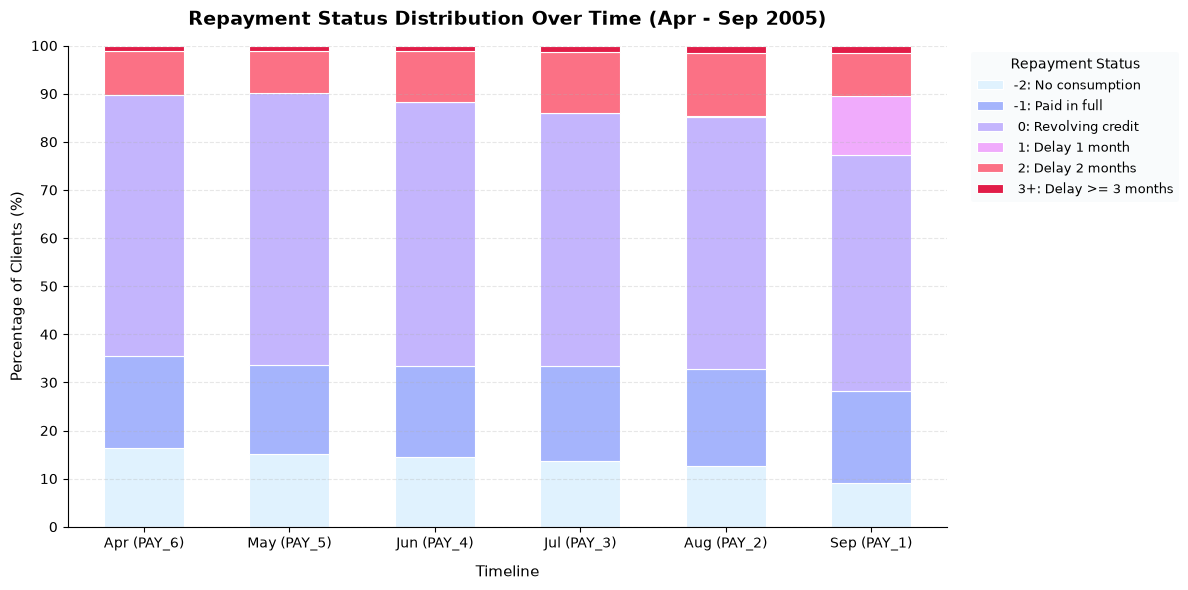

In [ ]:
pay_cols = ['PAY_6', 'PAY_5', 'PAY_4', 'PAY_3', 'PAY_2', 'PAY_1']
month_labels = [
    'Apr (PAY_6)',
    'May (PAY_5)',
    'Jun (PAY_4)',
    'Jul (PAY_3)',
    'Aug (PAY_2)',
    'Sep (PAY_1)',
]

# 1. Chuẩn hóa dữ liệu
df_temp = df[pay_cols].copy()


def clean_status(val):
  if pd.isna(val):
    return np.nan
  val_int = int(round(float(val)))
  return '3+' if val_int >= 3 else str(val_int)


for col in pay_cols:
  df_temp[col] = df_temp[col].apply(clean_status)

order = ['-2', '-1', '0', '1', '2', '3+']
status_labels = {
    '-2': '-2: No consumption',
    '-1': '-1: Paid in full',
    '0': ' 0: Revolving credit',
    '1': ' 1: Delay 1 month',
    '2': ' 2: Delay 2 months',
    '3+': ' 3+: Delay >= 3 months',
}

pay_pct = pd.concat(
    [df_temp[col].value_counts(normalize=True) * 100 for col in pay_cols],
    axis=1,
)
pay_pct = pay_pct.reindex(order).fillna(0).T
pay_pct.index = month_labels
pay_pct.columns = [status_labels[c] for c in order]

pastel_palette = [
    '#E0F2FE', 
    '#A5B4FC', 
    '#C4B5FD',  
    '#F0ABFC',  
    '#FB7185',  
    '#E11D48',  
]

fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

pay_pct.plot(
    kind='bar',
    stacked=True,
    color=pastel_palette,
    ax=ax,
    edgecolor='white',
    linewidth=0.8,
    width=0.55,
)

plt.title(
    'Repayment Status Distribution Over Time (Apr - Sep 2005)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Timeline', fontsize=11, labelpad=10)
plt.ylabel('Percentage of Clients (%)', fontsize=11)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(np.arange(0, 101, 10))
plt.ylim(0, 100)

plt.legend(
    title='Repayment Status',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True,
    facecolor='#F8FAFC',
    edgecolor='none',
    fontsize=9.5,
)

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

Between April and September 2005, the credit portfolio maintains a solid baseline of compliant borrowers (~85%–90%), but shows a clear structural migration from inactive accounts toward active debt and early-stage delinquency by late Q3.

Zero-consumption clients (-2) decline steadily from 16.3% in April to 9.2% in September. Inactive cardholders are progressively drawing down their credit limits over time, expanding the active borrowing pool.

In September (PAY_1), 12.3% of clients transition into a 1-month payment delay (1). This influx directly absorbs former revolvers (0) and newly activated clients (-2), marking the entry point of fresh default risk into the portfolio.

Fully compliant clients (-1) remain remarkably stable at ~19%–20% across all 6 months, showing that high-quality transactors maintain consistent repayment behavior.

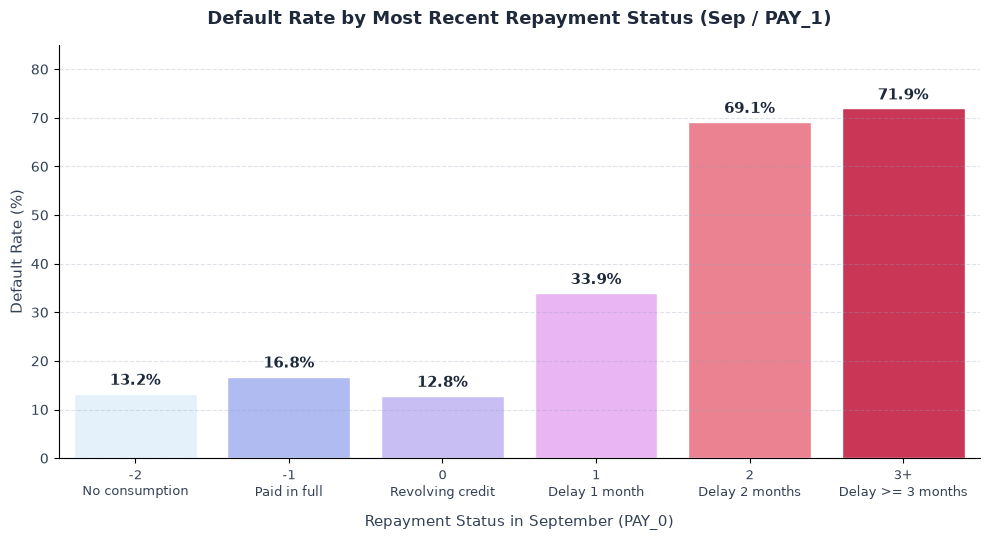

In [ ]:
df_temp = df.copy()
df_temp['PAY_1_grouped'] = df_temp['PAY_1'].apply(
    lambda x: '3+' if x >= 3 else str(int(x))
)

order = ['-2', '-1', '0', '1', '2', '3+']
labels = [
    '-2\nNo consumption',
    '-1\nPaid in full',
    '0\nRevolving credit',
    '1\nDelay 1 month',
    '2\nDelay 2 months',
    '3+\nDelay >= 3 months',
]

default_stats = (
    df_temp.groupby('PAY_1_grouped')['Default']
    .agg(total_clients='count', default_rate='mean')
    .reindex(order)
    .reset_index()
)
default_stats['default_rate_pct'] = default_stats['default_rate'] * 100

pastel_palette = [
    '#E0F2FE',  
    '#A5B4FC',  
    '#C4B5FD', 
    '#F0ABFC',  
    '#FB7185',  
    '#E11D48', 
]

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=100)

bars = sns.barplot(
    data=default_stats,
    x='PAY_1_grouped',
    y='default_rate_pct',
    palette=pastel_palette,
    hue='PAY_1_grouped',
    dodge=False,
    ax=ax,
    edgecolor='white',
    linewidth=1.0,
)

if ax.legend_:
  ax.legend_.remove()

for p in ax.patches:
  height = p.get_height()
  if not np.isnan(height) and height > 0:
    ax.annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        fontsize=10.5,
        fontweight='bold',
        color='#1E293B',
        xytext=(0, 4),
        textcoords='offset points',
    )

plt.title(
    'Default Rate by Most Recent Repayment Status (Sep / PAY_1)',
    fontsize=13,
    fontweight='bold',
    pad=15,
    color='#1E293B',
)
plt.xlabel(
    'Repayment Status in September (PAY_0)',
    fontsize=11,
    labelpad=10,
    color='#334155',
)
plt.ylabel('Default Rate (%)', fontsize=11, color='#334155')
plt.xticks(ticks=range(len(order)), labels=labels, fontsize=9.5, color='#334155')
plt.yticks(np.arange(0, 91, 10), color='#334155')
plt.ylim(0, 85)

plt.grid(axis='y', linestyle='--', alpha=0.3, color='#94A3B8')
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

The most recent repayment status (PAY_0) exhibits a sharp, non-linear risk escalation, establishing a critical tipping point at a 1-month delay (PAY_0 = 1) and a high-risk plateau once delinquency reaches 2+ months (PAY_0 ≥ 2).

Non-delinquent borrowers—zero consumption (-2), paid in full (-1), and active revolving credit (0)—maintain a low default probability clustered between 12.8% and 16.8%.

A single month of payment delay causes the default rate to jump to 33.9% (nearly 2.7 times higher than the revolving baseline of 12.8%). This represents the primary entry threshold for distressed borrowers.

Escalating to a 2-month delay causes the default rate to surge to 69.1%, eventually plateauing at 71.9% for delays of 3 months or more (3+). Seven out of ten clients in this bucket fail to settle their next invoice.

### 1.4. Split data into 2 train/test sets

In [10]:
X = df.drop(columns=['ID', 'Default'])
y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


## STEP 2. DATA PREPROCESSING 

### Numerical and categorical

In [50]:
columns_df = df.columns
columns_df

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default',
       'UTIL_RATIO_1', 'UTIL_RATIO_2', 'UTIL_RATIO_3', 'UTIL_RATIO_4',
       'UTIL_RATIO_5', 'UTIL_RATIO_6', 'AVG_UTIL_RATIO', 'PAY_RATIO_1',
       'PAY_RATIO_2', 'PAY_RATIO_3', 'PAY_RATIO_4', 'PAY_RATIO_5',
       'AVG_PAY_RATIO', 'TOTAL_DELAY_MONTHS', 'EVER_SERIOUS_DELAY'],
      dtype='object')

In [51]:
X.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'UTIL_RATIO_1', 'UTIL_RATIO_2', 'UTIL_RATIO_3', 'UTIL_RATIO_4',
       'UTIL_RATIO_5', 'UTIL_RATIO_6', 'AVG_UTIL_RATIO', 'PAY_RATIO_1',
       'PAY_RATIO_2', 'PAY_RATIO_3', 'PAY_RATIO_4', 'PAY_RATIO_5',
       'AVG_PAY_RATIO', 'TOTAL_DELAY_MONTHS', 'EVER_SERIOUS_DELAY'],
      dtype='object')

In [52]:
features_lst = list(X.columns)
features_lst

['LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_1',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'UTIL_RATIO_1',
 'UTIL_RATIO_2',
 'UTIL_RATIO_3',
 'UTIL_RATIO_4',
 'UTIL_RATIO_5',
 'UTIL_RATIO_6',
 'AVG_UTIL_RATIO',
 'PAY_RATIO_1',
 'PAY_RATIO_2',
 'PAY_RATIO_3',
 'PAY_RATIO_4',
 'PAY_RATIO_5',
 'AVG_PAY_RATIO',
 'TOTAL_DELAY_MONTHS',
 'EVER_SERIOUS_DELAY']

In [11]:
categorical_cols = [
    'SEX',
    'EDUCATION',
    'MARRIAGE'
]

ordinal_cols = [
    'PAY_1',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6'
]

binary_cols = [
    'EVER_SERIOUS_DELAY'
]

numerical_cols = [
    'LIMIT_BAL',
    'AGE',
    'BILL_AMT1',
    'BILL_AMT2',
    'BILL_AMT3',
    'BILL_AMT4',
    'BILL_AMT5',
    'BILL_AMT6',
    'PAY_AMT1',
    'PAY_AMT2',
    'PAY_AMT3',
    'PAY_AMT4',
    'PAY_AMT5',
    'PAY_AMT6',
    'UTIL_RATIO_1',
    'UTIL_RATIO_2',
    'UTIL_RATIO_3',
    'UTIL_RATIO_4',
    'UTIL_RATIO_5',
    'UTIL_RATIO_6',
    'AVG_UTIL_RATIO',
    'PAY_RATIO_1',
    'PAY_RATIO_2',
    'PAY_RATIO_3',
    'PAY_RATIO_4',
    'PAY_RATIO_5',
    'AVG_PAY_RATIO',
    'TOTAL_DELAY_MONTHS'
]

### Scalling and Encoding

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [14]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

## STEP 3: PREDICTIVE MODEL

### 3.1. Logistic Regression

In [17]:
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ]
)
logistic_model.fit(X_train, y_train)
y_pred = logistic_model.predict(X_test)

# Probability of class 1 (Default)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.76
Precision: 0.46265697290152014
Recall   : 0.5275056518462697
F1-score : 0.49295774647887325
ROC-AUC  : 0.7379567174767069

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      4673
           1       0.46      0.53      0.49      1327

    accuracy                           0.76      6000
   macro avg       0.66      0.68      0.67      6000
weighted avg       0.77      0.76      0.77      6000


Confusion Matrix:
[[3860  813]
 [ 627  700]]


### 3.2. Random Forest 

In [20]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        ('model', RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.7836666666666666
Precision: 0.5112316034082107
Recall   : 0.49736247174076864
F1-score : 0.5042016806722689
ROC-AUC  : 0.7535347523032715

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      4673
           1       0.51      0.50      0.50      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.68      0.68      6000
weighted avg       0.78      0.78      0.78      6000


Confusion Matrix:
[[4042  631]
 [ 667  660]]


### 3.3. XGBoost

In [30]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

xgb_tuned = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        ('model', xgb.XGBClassifier(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=3,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.5,
            scale_pos_weight=3.52,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ))
    ]
)


xgb_tuned.fit(X_train, y_train)
y_pred = xgb_tuned.predict(X_test)
y_prob = xgb_tuned.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.746
Precision: 0.4485101934134867
Recall   : 0.6465712132629993
F1-score : 0.5296296296296297
ROC-AUC  : 0.771065917484254

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      4673
           1       0.45      0.65      0.53      1327

    accuracy                           0.75      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.75      0.76      6000


Confusion Matrix:
[[3618 1055]
 [ 469  858]]


Among the three evaluated models, XGBoost achieved the best overall performance for identifying default customers. Although Random Forest obtained the highest accuracy and precision, XGBoost achieved the highest recall (64.7%), F1-score (53.0%), and ROC-AUC (77.1%). Since identifying potential default customers is more important than maximizing overall accuracy in this credit risk problem, XGBoost was selected as the final model.

### 3.4. Identify Importance Features

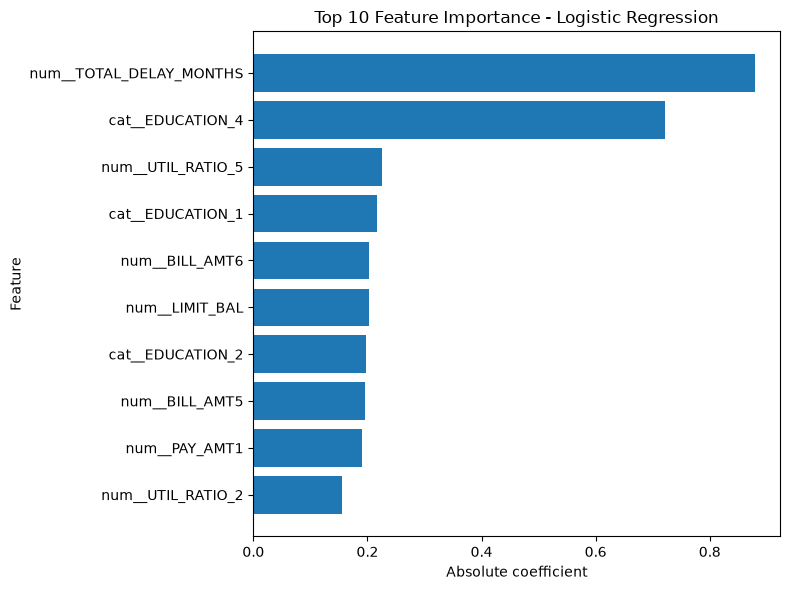

In [33]:
feature_names = xgb_tuned.named_steps["preprocessor"].get_feature_names_out()
# 1. Logistic Regression
log_clf = logistic_model.named_steps["model"]

log_importance = np.abs(log_clf.coef_[0])

log_df = pd.DataFrame({
    "feature": feature_names,
    "importance": log_importance
})

log_df = (
    log_df
    .sort_values("importance", ascending=False)
    .head(10)
    .sort_values("importance")
)

plt.figure(figsize=(8, 6))
plt.barh(log_df["feature"], log_df["importance"])
plt.xlabel("Absolute coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Logistic Regression")
plt.tight_layout()
plt.show()

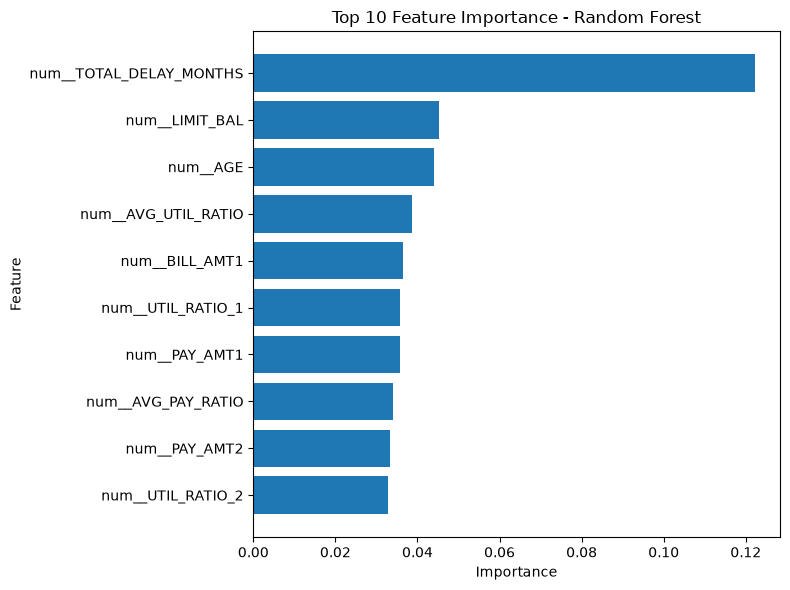

In [34]:
# 2. Random Forest

rf_clf = rf_model.named_steps["model"]

rf_importance = rf_clf.feature_importances_

rf_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_importance
})

rf_df = (
    rf_df
    .sort_values("importance", ascending=False)
    .head(10)
    .sort_values("importance")
)

plt.figure(figsize=(8, 6))
plt.barh(rf_df["feature"], rf_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

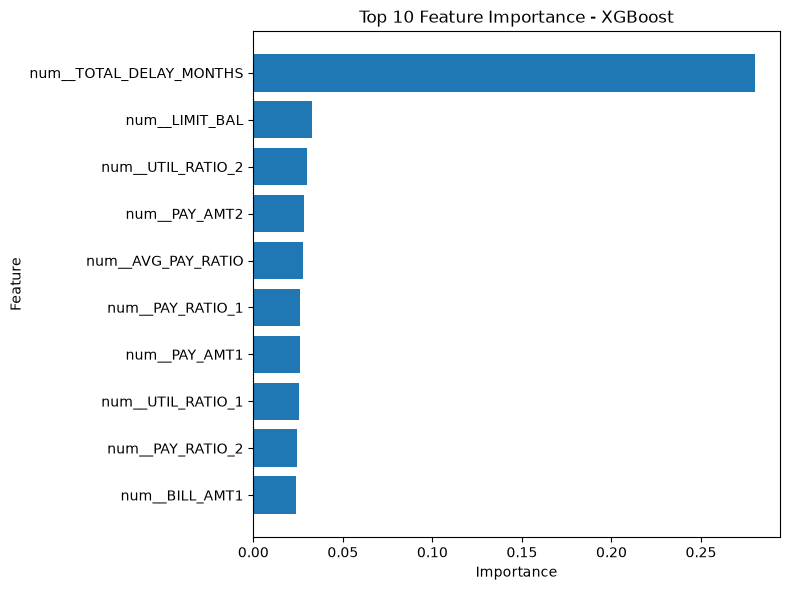

In [36]:
# 3. XGBoost

xgb_clf = xgb_tuned.named_steps["model"]

xgb_importance = xgb_clf.feature_importances_

xgb_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_importance
})

xgb_df = (
    xgb_df
    .sort_values("importance", ascending=False)
    .head(10)
    .sort_values("importance")
)

plt.figure(figsize=(8, 6))
plt.barh(xgb_df["feature"], xgb_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - XGBoost")
plt.tight_layout()
plt.show()

TOTAL_DELAY_MONTHS was the most important feature across all three models, indicating that payment delay history is strongly associated with default prediction. Other consistently important features include LIMIT_BAL, credit utilization ratios, payment amounts, and payment ratios.

Random Forest and XGBoost showed similar patterns, with greater importance placed on customers’ financial and payment behavior. In comparison, Logistic Regression gave more importance to EDUCATION categories. Overall, the results suggest that payment history and credit utilization are the main factors contributing to default prediction.